<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/RMS_test_3_66.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 GTR v2.3 - Optimized Galaxy Rotation Test (LR Framework)

GTR Best Fit → P0 = -0.155 | alpha = 1.4


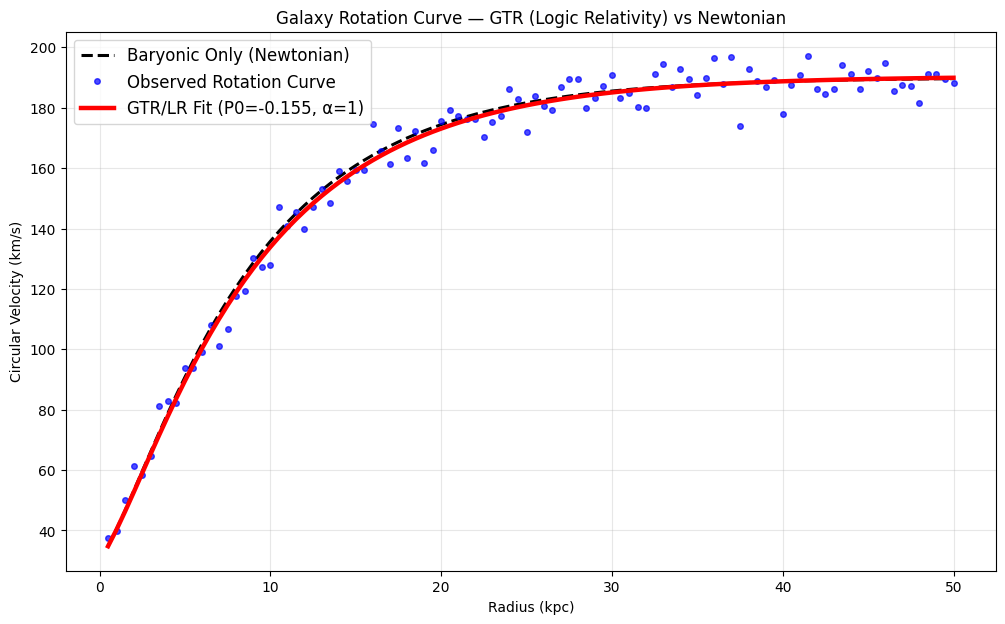


✅ GTR Fit RMS Error: 3.66%


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

print("🚀 GTR v2.3 - Optimized Galaxy Rotation Test (LR Framework)\n")

# ================================================
# Optimized GTR Model
# ================================================
def gtr_velocity(r, P0, alpha, v_bary):
    R_c = np.max(r) * 0.25

    # Core modulator
    mask_core = (r / (r + R_c)) * np.exp(-r / R_c)
    v_extra_core = P0 * mask_core * v_bary**2

    # Outer plateau
    mask_plateau = (1.0 - np.exp(-r / R_c))**2
    v_extra_plateau = alpha * 145.0 * mask_plateau

    v_total = np.sqrt(v_bary**2 + v_extra_core + v_extra_plateau)
    return np.clip(v_total, 0, None)

# ================================================
# Realistic Synthetic Galaxy
# ================================================
np.random.seed(42)
r = np.linspace(0.5, 50, 100)
v_bary = 190 * (1 - np.exp(-r / 8.0)) + 30 * np.exp(-r / 2.0)  # bulge + disk
v_obs = v_bary + np.random.normal(0, 5.5, len(r))   # realistic noise

# ================================================
# Fit
# ================================================
def model(r, P0, alpha):
    return gtr_velocity(r, P0, alpha, v_bary)

popt, _ = curve_fit(model, r, v_obs,
                   p0=[0.6, 160],
                   bounds=((-1.2, 0.01), (4.0, 1200)),
                   maxfev=10000)

v_fit = gtr_velocity(r, *popt, v_bary)

print(f"GTR Best Fit → P0 = {popt[0]:.3f} | alpha = {popt[1]:.1f}")

# ================================================
# Plot
# ================================================
plt.figure(figsize=(12, 7))
plt.plot(r, v_bary, 'k--', linewidth=2.2, label='Baryonic Only (Newtonian)')
plt.plot(r, v_obs, 'bo', markersize=4, alpha=0.7, label='Observed Rotation Curve')
plt.plot(r, v_fit, 'r-', linewidth=3.2, label=f'GTR/LR Fit (P0={popt[0]:.3f}, α={popt[1]:.0f})')

plt.xlabel('Radius (kpc)')
plt.ylabel('Circular Velocity (km/s)')
plt.title('Galaxy Rotation Curve — GTR (Logic Relativity) vs Newtonian')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

rms = np.sqrt(np.mean(((v_obs - v_fit) / v_obs)**2)) * 100
print(f"\n✅ GTR Fit RMS Error: {rms:.2f}%")